# Анализ сайта «СберАвтоподписка» — ML

**Задача:** по данным о визите предсказать, оставит ли пользователь заявку (целевое действие).
**Метрика:** ROC-AUC, ориентир заказчика ~0.65.
**Данные:** Google Analytics — сессии (визиты) и хиты (события на сайте).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score


In [ ]:
hits = pd.read_pickle('/Users/kamola/Downloads/ga_hits.pkl')
hits[['session_id', 'event_action']].to_pickle('/Users/kamola/Downloads/ga_hits_slim.pkl')

In [2]:
df_session = pd.read_pickle('/Users/kamola/Downloads/ga_sessions.pkl')
df_session.shape

(1860042, 18)

In [3]:
df_hit = pd.read_pickle('/Users/kamola/Downloads/ga_hits_slim.pkl')
df_hit.shape

(15726470, 2)

In [4]:
df_session.info()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [5]:
df_hit.info()

<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 2 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   session_id    object
 1   event_action  object
dtypes: object(2)
memory usage: 240.0+ MB


In [6]:
df_session.head()


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [7]:
df_hit.head()

,session_id,event_action
0,5639623078712724064.1640254056.1640254056,quiz_show
1,7750352294969115059.1640271109.1640271109,quiz_show
2,885342191847998240.1640235807.1640235807,quiz_show
3,142526202120934167.1640211014.1640211014,quiz_show
4,3450086108837475701.1640265078.1640265078,quiz_show


## Подготовка и чистка данных

Что сделала:
- убрала `device_model` (99% пустых) и `client_id` (это id, не признак);
- нашла скрытые пропуски: `(not set)` — это тоже пропуск, просто строкой. Заменила их на NaN, потом всё закрыла меткой `unknown`;
- `(none)` в `utm_medium` не трогала — по глоссарию это органический трафик, а не пропуск;
- из даты вытащила час визита и день недели (`visit_hour`, `visit_dow`) — пригодятся как признаки.

In [8]:
df_session.isna().mean().sort_values()

session_id                  0.000000
device_browser              0.000000
device_screen_resolution    0.000000
device_category             0.000000
geo_country                 0.000000
utm_medium                  0.000000
geo_city                    0.000000
visit_number                0.000000
visit_time                  0.000000
visit_date                  0.000000
client_id                   0.000000
utm_source                  0.000052
device_brand                0.063804
utm_campaign                0.118063
utm_adcontent               0.180434
device_os                   0.575330
utm_keyword                 0.581740
device_model                0.991216
dtype: float64

In [9]:
df_hit.isna().mean().sort_values()

session_id      0.0
event_action    0.0
dtype: float64

In [10]:
df_session.nunique()

session_id                  1860042
client_id                   1391719
visit_date                      226
visit_time                    85318
visit_number                    537
utm_source                      293
utm_medium                       56
utm_campaign                    412
utm_adcontent                   286
utm_keyword                    1219
device_category                   3
device_os                        13
device_brand                    206
device_model                    104
device_screen_resolution       5039
device_browser                   57
geo_country                     166
geo_city                       2548
dtype: int64

In [11]:
df_hit.nunique()

session_id      1734610
event_action        230
dtype: int64

In [12]:
df_session.duplicated().sum()

np.int64(0)

In [13]:
df_session = df_session.drop(columns=['device_model', 'client_id'])

In [14]:
df_session = df_session.replace('(not set)', pd.NA)

In [15]:
cols = ['utm_keyword', 'device_os', 'device_brand', 'utm_campaign', 'utm_adcontent']
df_session[cols] = df_session[cols].fillna('unknown')

In [16]:
df_session.isna().mean().sort_values(ascending=False).head()

geo_city          0.042027
geo_country       0.000616
utm_medium        0.000258
utm_source        0.000052
device_browser    0.000009
dtype: float64

In [17]:
df_session = df_session.fillna('unknown')

In [18]:
df_session.isna().sum().sum()

np.int64(0)

In [19]:
df_session['visit_date'] = pd.to_datetime(df_session['visit_date'])
df_session['visit_dow'] = df_session['visit_date'].dt.dayofweek

In [20]:
df_session['visit_hour'] = pd.to_datetime(df_session['visit_time'], format='%H:%M:%S').dt.hour


In [21]:
df_session[['visit_date', 'visit_time', 'visit_hour', 'visit_dow']].head()
df_session.dtypes

session_id                         object
visit_date                  datetime64[s]
visit_time                         object
visit_number                        int64
utm_source                         object
utm_medium                         object
utm_campaign                       object
utm_adcontent                      object
utm_keyword                        object
device_category                    object
device_os                          object
device_brand                       object
device_screen_resolution           object
device_browser                     object
geo_country                        object
geo_city                           object
visit_dow                           int32
visit_hour                          int32
dtype: object

## Разведочный анализ (EDA)

Смотрю на распределения и связь признаков с конверсией.

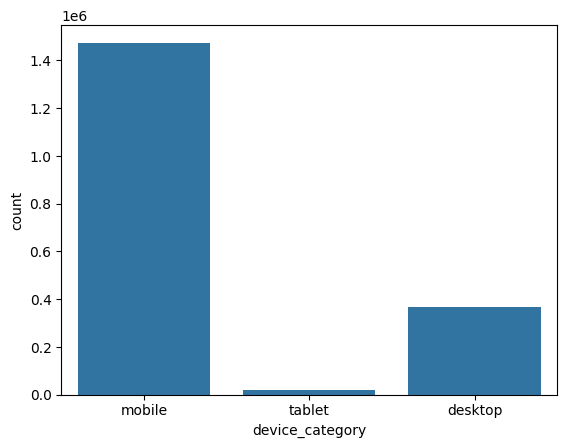

In [22]:
sns.countplot(data=df_session, x='device_category')
plt.show()

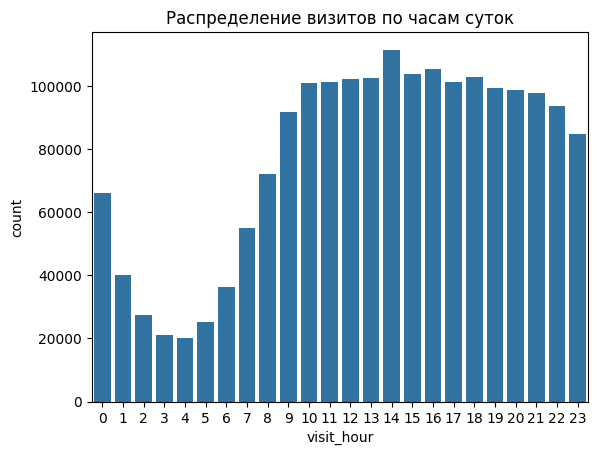

In [23]:
sns.countplot(data=df_session, x='visit_hour')
plt.title('Распределение визитов по часам суток')
plt.show()

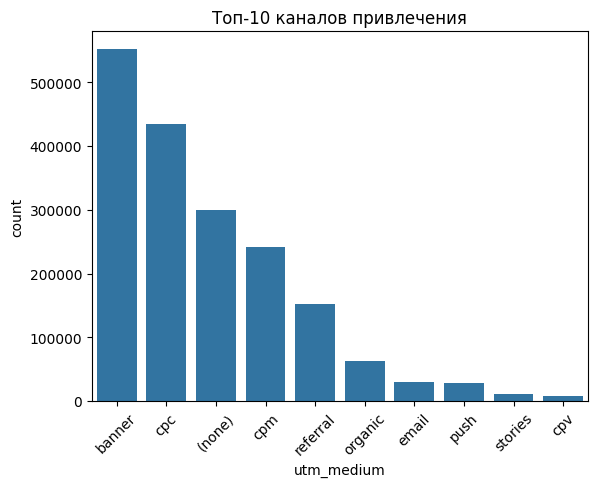

In [24]:
top10 = df_session['utm_medium'].value_counts().head(10).index
sns.countplot(data=df_session, x='utm_medium', order=top10)
plt.title('Топ-10 каналов привлечения')
plt.xticks(rotation=45)
plt.show()

**Выводы по распределениям:**
- ~80% визитов с мобильных, десктоп и планшеты сильно меньше;
- по часам — провал ночью, плато днём (9–21), пик около 14 часов;
- по каналам лидируют `banner` и `cpc` (платные), но и органики много (`(none)`, `referral`).

## Целевая переменная

Целевое действие беру из хитов (8 событий из глоссария). Логика:
1. помечаю целевые события в хитах;
2. для каждого визита беру максимум — был ли хоть один целевой клик;
3. приклеиваю к сессиям (left join, чтобы не потерять визиты без событий);
4. визиты без событий = 0 (зашёл и ушёл, ничего не нажал).

In [25]:
target_actions = ['sub_car_claim_click', 'sub_car_claim_submit_click',
                  'sub_open_dialog_click', 'sub_custom_question_submit_click',
                  'sub_call_number_click', 'sub_callback_submit_click',
                  'sub_submit_success', 'sub_car_request_submit_click']

In [26]:
df_hit['is_target'] = df_hit['event_action'].isin(target_actions).astype(int)

In [27]:
df_hit['is_target'].sum()

np.int64(104908)

In [28]:
target_per_session = df_hit.groupby('session_id')['is_target'].max()

In [29]:
print(target_per_session.shape)  
print(target_per_session.sum())

(1734610,)
50760


In [30]:
target_df = target_per_session.reset_index() 
target_df = target_df.rename(columns={'is_target': 'target'})

In [31]:
df_session = df_session.merge(target_df, on='session_id', how='left')

In [32]:
print(df_session.shape)


(1860042, 19)


In [33]:
print(df_session['target'].isna().sum())

127776


In [34]:
df_session['target'] = df_session['target'].fillna(0).astype(int)

In [35]:
print(df_session['target'].mean())
print(df_session['target'].value_counts())

0.027049926829609224
target
0    1809728
1      50314
Name: count, dtype: int64


**Итог: конверсия ≈ 2.7%** (50 314 заявок из 1.86 млн визитов).
Классы сильно несбалансированы (~36:1) — поэтому метрика ROC-AUC, а не accuracy.

### Конверсия по группам

Смотрю, как доля заявок (target) зависит от устройства и канала привлечения.

In [36]:
df_session.groupby('device_category')['target'].mean()

device_category
desktop    0.031382
mobile     0.026022
tablet     0.023050
Name: target, dtype: float64

In [37]:
df_session.groupby('utm_medium')['target'].mean().sort_values(ascending=False)

utm_medium
dom_click            1.000000
link                 0.298246
landing              0.141791
medium               0.125000
social               0.111111
CPM                  0.075000
sms                  0.066946
unknown              0.058333
referral             0.053805
static               0.045455
clicks               0.044968
smm                  0.043829
(none)               0.035036
organic              0.033315
cpa                  0.030615
push                 0.029963
yandex_cpc           0.027778
banner               0.027354
smartbanner          0.026347
post                 0.023216
cpc                  0.021916
blogger_channel      0.020212
fb_smm               0.015152
cpv                  0.014336
outlook              0.014264
email                0.013714
tg                   0.012715
stories              0.011907
cpm                  0.010406
partner              0.010309
blogger_stories      0.008117
info_text            0.005831
app                  0.003879

In [38]:
df_session.groupby('utm_medium')['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
utm_medium,,
dom_click,1.000000,1
link,0.298246,57
landing,0.141791,134
medium,0.125000,8
social,0.111111,9
CPM,0.075000,40
sms,0.066946,239
unknown,0.058333,480
referral,0.053805,152050


**Выводы по группам:**
- desktop конвертит лучше (3.1%), чем mobile (2.6%) и tablet (2.3%);
- органический трафик даёт ~4% против ~2.2% у платного — почти вдвое выше;
- важно смотреть не только на %, но и на count: у мелких каналов 100% — это случайность на паре заходов, а не закономерность.

In [39]:
organic_mediums = ['organic', 'referral', '(none)']
df_session['is_organic'] = df_session['utm_medium'].isin(organic_mediums).astype(int)

In [40]:
print(df_session['is_organic'].value_counts())
print(df_session.groupby('is_organic')['target'].mean())

is_organic
0    1344383
1     515659
Name: count, dtype: int64
is_organic
0    0.021945
1    0.040360
Name: target, dtype: float64


**Фича `is_organic`** (органика/платный по глоссарию): органика конвертит ~4.0% против ~2.2% у платного. Разница хорошая — значит признак несёт сигнал.

In [41]:
features = ['visit_number', 'visit_hour', 'visit_dow',
            'device_category', 'device_os', 'device_browser', 'is_organic']

x = df_session[features]
y = df_session['target']

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)


## Модель

Признаки: время визита, источники (`utm_*`), устройство, гео + своя фича `is_organic`.
Идентификаторы (`session_id`, `client_id`) и сырые даты в модель не беру.
Деление train/test — 70/30 со стратификацией, чтобы доля заявок сохранилась в обеих частях.

**Бейзлайн** — логистическая регрессия, чтобы было с чем сравнивать.

In [43]:
num_features = ['visit_number', 'visit_hour', 'visit_dow', 'is_organic']
cat_features = ['device_category', 'device_os', 'device_browser']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat

In [56]:
y_proba = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print('ROC-AUC baseline:', auc)


ROC-AUC baseline: 0.643406574708369


**CatBoost с полным набором фич.**
Беру бустинг, т.к. данные табличные с кучей категорий — для такого он почти всегда лучше нейросетей и проще в работе. Он сам обрабатывает категории, one-hot не нужен. Добавляю сильные фичи, которые раньше откладывала из-за высокой кардинальности (`geo_city`, `utm_source` и т.д.) — CatBoost их тянет.
Дисбаланс лечу через `auto_class_weights='Balanced'`.

In [57]:
num_features = ['visit_number', 'visit_hour', 'visit_dow']
cat_features = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
                'device_category', 'device_os', 'device_brand', 'device_browser',
                'geo_country', 'geo_city']
extra_features = ['is_organic']

features = num_features + cat_features + extra_features

x = df_session[features]
y = df_session['target']

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

x_train[cat_features] = x_train[cat_features].astype(str)
x_test[cat_features] = x_test[cat_features].astype(str)

In [60]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_state=42,
    verbose=50
)

model.fit(x_train, y_train, eval_set=(x_test, y_test))

y_proba = model.predict_proba(x_test)[:, 1]
print('ROC-AUC CatBoost:', roc_auc_score(y_test, y_proba))


0:	test: 0.6537022	best: 0.6537022 (0)	total: 434ms	remaining: 2m 9s
50:	test: 0.6931913	best: 0.6931913 (50)	total: 17.3s	remaining: 1m 24s
100:	test: 0.6981580	best: 0.6981580 (100)	total: 34.7s	remaining: 1m 8s
150:	test: 0.7002917	best: 0.7002917 (150)	total: 55.6s	remaining: 54.8s
200:	test: 0.7029223	best: 0.7029223 (200)	total: 1m 18s	remaining: 38.8s
250:	test: 0.7037856	best: 0.7038231 (233)	total: 1m 41s	remaining: 19.7s
299:	test: 0.7043130	best: 0.7043190 (297)	total: 2m 1s	remaining: 0us

bestTest = 0.7043189666
bestIteration = 297

Shrink model to first 298 iterations.
ROC-AUC CatBoost: 0.7043189666096199


**Результаты:**
- Логистическая регрессия (бейзлайн): ROC-AUC **0.604**
- CatBoost, базовые фичи: **0.643**
- CatBoost + источники и гео: **0.704** ✅

Цель 0.65 перебили. Видно, что добавление сильных фич дало больше прироста, чем смена модели — данные важнее алгоритма.

In [61]:
importances = pd.DataFrame({
    'feature': model.feature_names_,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print(importances)

            feature  importance
5      utm_campaign   16.990793
6     utm_adcontent   14.292857
3        utm_source   13.476783
0      visit_number    8.919643
8         device_os    7.415185
4        utm_medium    7.268799
10   device_browser    6.025803
1        visit_hour    5.738973
11      geo_country    4.549235
9      device_brand    4.213392
7   device_category    4.097997
12         geo_city    3.593267
2         visit_dow    1.917741
13       is_organic    1.499532


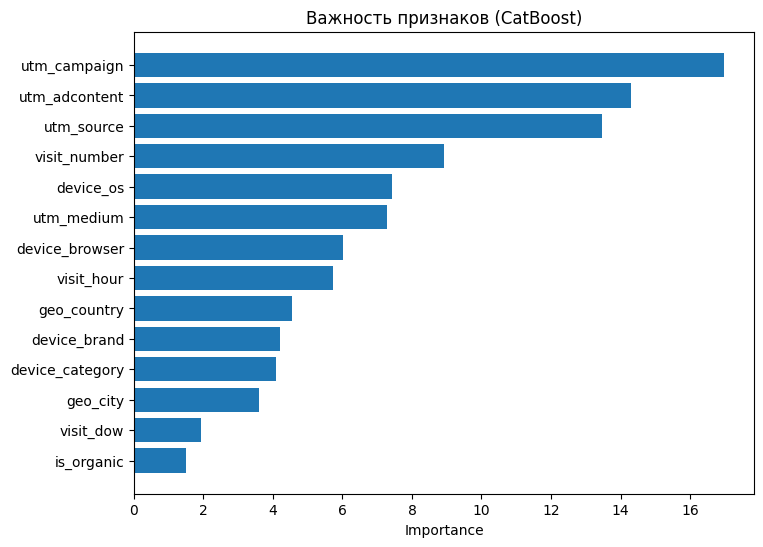

In [64]:
plt.figure(figsize=(8, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()   # чтобы самая важная была сверху
plt.title('Важность признаков (CatBoost)')
plt.xlabel('Importance')
plt.show()

**Важность признаков:**
В топе — `utm_campaign`, `utm_adcontent`, `utm_source`: сильнее всего на конверсию влияет **источник трафика**. Совпадает с EDA.

`is_organic` оказалась внизу — она дублирует `utm_medium`, а у модели есть фичи побогаче. Для модели избыточна, но как понятный человеку признак оставляю.

**Вывод для бизнеса:** конверсией управляют через каналы и кампании. Органика конвертит лучше платного — есть смысл в неё вкладываться.

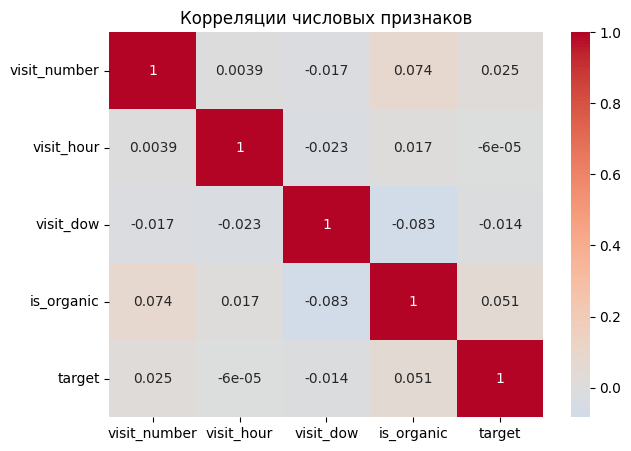

In [66]:
num_cols = ['visit_number', 'visit_hour', 'visit_dow', 'is_organic', 'target']
corr = df_session[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков')
plt.show()

**Корреляции:**
Числовые признаки слабо коррелируют с target (всё близко к нулю). Это нормально: основной сигнал — в категориальных признаках (источники), а корреляция Пирсона их не видит. Подтверждается важностью фич — там в топе именно категории.

In [65]:
model.save_model('catboost_model.cbm')

## Итоги

- Построена модель предсказания заявки, ROC-AUC **0.704** (> 0.65).
- Главный фактор конверсии — источник трафика; органика эффективнее платного.
- Модель сохранена (`catboost_model.cbm`), сервис предсказания — в `predict.py`.

**Запуск сервиса:** `python predict.py` (модель должна лежать в той же папке).